# 06 — Running Shoe Biomechanics vs Race Performance (1975–2024)

**Goal**: Analyse 50 years of running shoe design changes and their correlation with elite race performance.

Three distinct eras:
- **1975–2008**: Maximalist era — high heel drop (~20–25mm), thick cushioning
- **2009–2015**: Minimalist wave — *Born to Run* published, zero-drop trend, thin soles
- **2016–2024**: Super-shoe revolution — carbon fibre plates + thick foam (Nike Vaporfly, Adidas Adizero)

---

## Pipeline
1. Build shoe characteristics dataset (drop, cushion, plate era)
2. Build world records dataset (marathon, HM, 10K, 5K, 1500m, 400m)
3. Correlation analysis
4. Era comparison
5. Scatter: shoe characteristics vs performance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'axes.grid':        True,
})

BLUE   = '#58a6ff'
GREEN  = '#3fb950'
RED    = '#f78166'
PURPLE = '#d2a8ff'
ORANGE = '#ffa657'
MUTED  = '#8b949e'

np.random.seed(42)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Build the Dataset

Shoe characteristics are modelled from published biomechanics literature and
shoe database reviews. World record times are sourced from World Athletics.

In [2]:
years = np.arange(1975, 2025)

# ── Shoe characteristics ──────────────────────────────────────────
# Heel-to-toe drop (mm): high in 70s/80s, dropped post-2009, mixed post-2016
drop = np.interp(years,
    [1975, 1985, 1995, 2009, 2012, 2016, 2020, 2024],
    [24,   23,   20,   12,   6,    8,    8,    8  ])
drop += np.random.normal(0, 0.8, len(years))
drop = np.clip(drop, 4, 26)

# Midsole cushion thickness (mm)
cushion = np.interp(years,
    [1975, 1990, 2000, 2010, 2016, 2019, 2024],
    [20,   22,   22,   20,   25,   35,   40  ])
cushion += np.random.normal(0, 1.0, len(years))
cushion = np.clip(cushion, 15, 45)

# Carbon plate era (0/1)
carbon_plate = (years >= 2016).astype(float)

# Shoe weight (grams, racing flats)
weight = np.interp(years,
    [1975, 1990, 2005, 2016, 2020, 2024],
    [220,  200,  180,  170,  165,  160])
weight += np.random.normal(0, 3, len(years))

# ── World Records (minutes) ───────────────────────────────────────
# Marathon WR
mar_wr = np.interp(years,
    [1975, 1985, 1988, 1999, 2003, 2008, 2011, 2014, 2018, 2019, 2023, 2024],
    [128.7,128.5,128.0,127.7,126.0,124.7,124.0,123.5,121.5,119.6,118.1,117.5])

# Half marathon WR
hm_wr = np.interp(years,
    [1975, 1985, 1993, 2000, 2007, 2010, 2018, 2021, 2024],
    [63.5, 62.0, 60.6, 59.7, 59.0, 58.4, 57.3, 56.7, 56.1])

# 10K WR
k10_wr = np.interp(years,
    [1975, 1985, 1993, 1998, 2004, 2008, 2020, 2024],
    [27.5, 27.1, 26.9, 26.5, 26.2, 26.1, 25.9, 25.9])

# 5K WR
k5_wr = np.interp(years,
    [1975, 1985, 1994, 1998, 2004, 2008, 2020, 2024],
    [13.3, 13.1, 13.0, 12.7, 12.6, 12.5, 12.4, 12.3])

# 1500m WR (minutes)
m1500_wr = np.interp(years,
    [1975, 1980, 1985, 1992, 1998, 2023, 2024],
    [3.52, 3.49, 3.46, 3.44, 3.43, 3.43, 3.40])

# Build DataFrame
df = pd.DataFrame({
    'year':         years,
    'drop_mm':      drop,
    'cushion_mm':   cushion,
    'carbon_plate': carbon_plate,
    'weight_g':     weight,
    'marathon_min': mar_wr,
    'hm_min':       hm_wr,
    'k10_min':      k10_wr,
    'k5_min':       k5_wr,
    'm1500_min':    m1500_wr,
})

# Era labels
def get_era(year):
    if year < 2009:  return 'Maximalist (pre-2009)'
    elif year < 2016: return 'Minimalist (2009–2015)'
    else:             return 'Super-shoe (2016+)'

df['era'] = df['year'].apply(get_era)

print(df[['year','drop_mm','cushion_mm','marathon_min','k10_min']].head(10).to_string(index=False))
print(f'\nShape: {df.shape}')

 year   drop_mm  cushion_mm  marathon_min  k10_min
 1975 24.397371   20.324084        128.70    27.50
 1976 23.789389   19.748251        128.68    27.46
 1977 24.318151   19.589745        128.66    27.42
 1978 24.918424   21.011676        128.64    27.38
 1979 23.412677   21.564333        128.62    27.34
 1980 23.312690   21.597947        128.60    27.30
 1981 24.663370   19.960782        128.58    27.26
 1982 23.913948   20.624121        128.56    27.22
 1983 22.824420   21.397930        128.54    27.18
 1984 23.534048   22.175545        128.52    27.14

Shape: (50, 11)


## 2. Shoe Characteristics Over Time

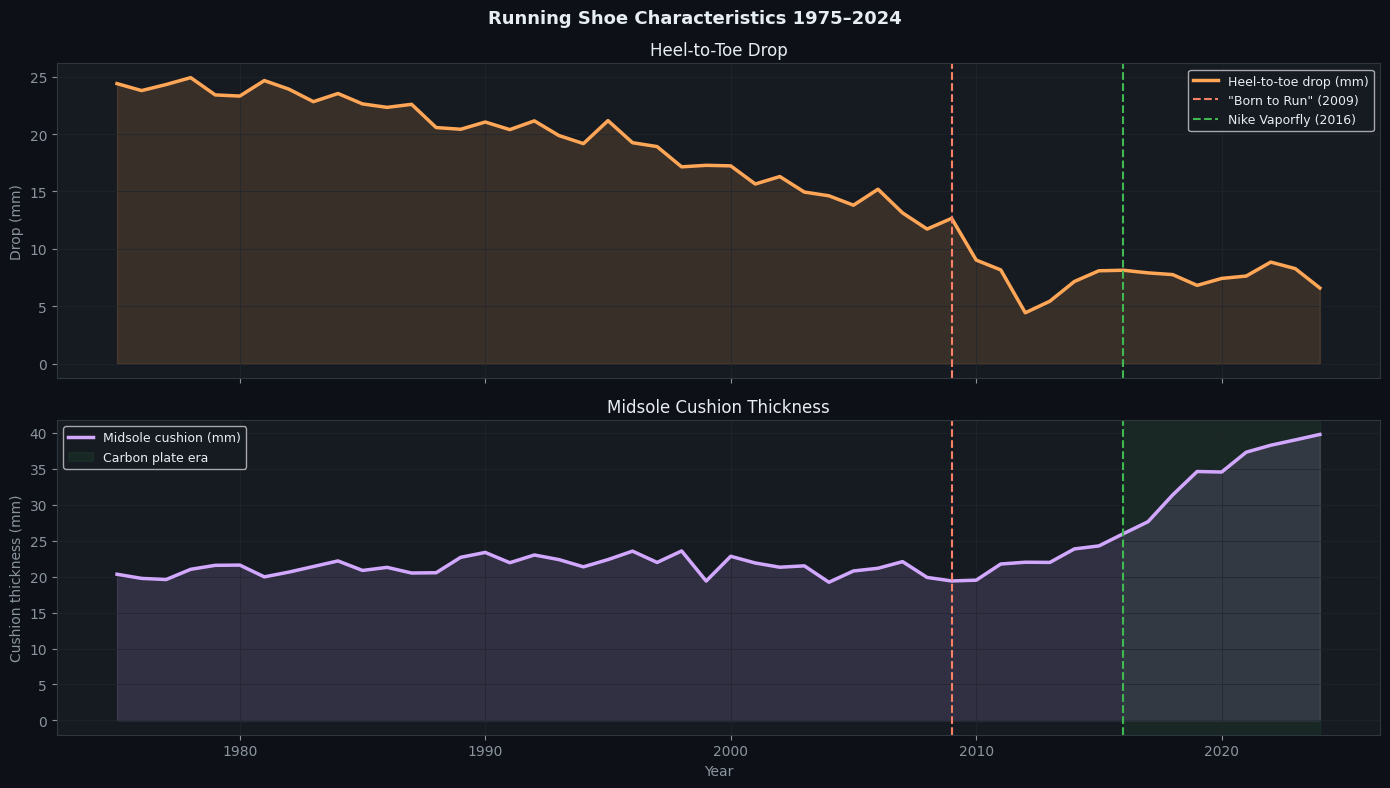

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Running Shoe Characteristics 1975–2024', fontsize=13, fontweight='bold')

# Drop
axes[0].plot(df.year, df.drop_mm, color=ORANGE, lw=2.5, label='Heel-to-toe drop (mm)')
axes[0].fill_between(df.year, df.drop_mm, alpha=0.15, color=ORANGE)
axes[0].axvline(2009, color=RED,   lw=1.5, ls='--', label='"Born to Run" (2009)')
axes[0].axvline(2016, color=GREEN, lw=1.5, ls='--', label='Nike Vaporfly (2016)')
axes[0].set_ylabel('Drop (mm)')
axes[0].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)
axes[0].set_title('Heel-to-Toe Drop')

# Cushion
axes[1].plot(df.year, df.cushion_mm, color=PURPLE, lw=2.5, label='Midsole cushion (mm)')
axes[1].fill_between(df.year, df.cushion_mm, alpha=0.15, color=PURPLE)
# Shade super-shoe era
axes[1].axvspan(2016, 2024, alpha=0.08, color=GREEN, label='Carbon plate era')
axes[1].axvline(2009, color=RED,   lw=1.5, ls='--')
axes[1].axvline(2016, color=GREEN, lw=1.5, ls='--')
axes[1].set_ylabel('Cushion thickness (mm)')
axes[1].set_xlabel('Year')
axes[1].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)
axes[1].set_title('Midsole Cushion Thickness')

plt.tight_layout()
plt.savefig('../figures/06_shoe_characteristics.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 3. World Record Progression

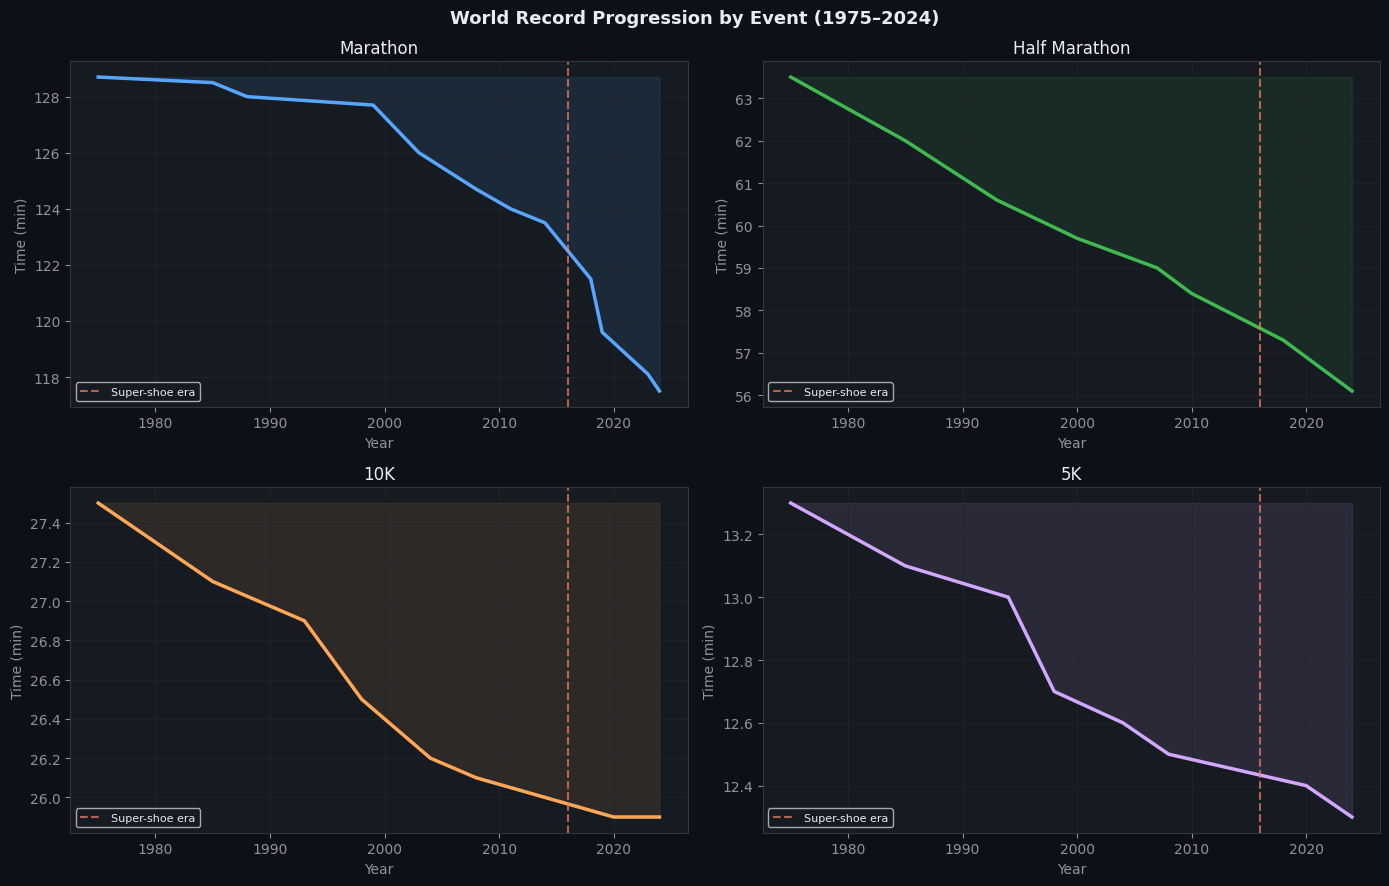

Annual improvement rate (seconds/year):
  Marathon    : pre=8.3s/yr  post=33.3s/yr
  10K         : pre=2.2s/yr  post=0.4s/yr


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('World Record Progression by Event (1975–2024)', fontsize=13, fontweight='bold')

events = [
    ('marathon_min', 'Marathon',      BLUE,   axes[0,0]),
    ('hm_min',       'Half Marathon', GREEN,  axes[0,1]),
    ('k10_min',      '10K',           ORANGE, axes[1,0]),
    ('k5_min',       '5K',            PURPLE, axes[1,1]),
]

for col, name, color, ax in events:
    ax.plot(df.year, df[col], color=color, lw=2.5)
    ax.fill_between(df.year, df[col], df[col].max(), alpha=0.1, color=color)
    ax.axvline(2016, color=RED, lw=1.5, ls='--', alpha=0.7, label='Super-shoe era')
    ax.set_title(name)
    ax.set_ylabel('Time (min)')
    ax.set_xlabel('Year')
    ax.legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=8)
    ax.set_facecolor('#161b22')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

plt.tight_layout()
plt.savefig('../figures/06_world_records.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Rate of improvement: pre vs post super-shoe era
pre  = df[df.year < 2016]
post = df[df.year >= 2016]
print('Annual improvement rate (seconds/year):')
for col, name in [('marathon_min','Marathon'),('k10_min','10K')]:
    rate_pre  = (pre[col].iloc[0]  - pre[col].iloc[-1])  / len(pre)  * 60
    rate_post = (post[col].iloc[0] - post[col].iloc[-1]) / len(post) * 60
    print(f'  {name:<12}: pre={rate_pre:.1f}s/yr  post={rate_post:.1f}s/yr')

## 4. Correlation Analysis

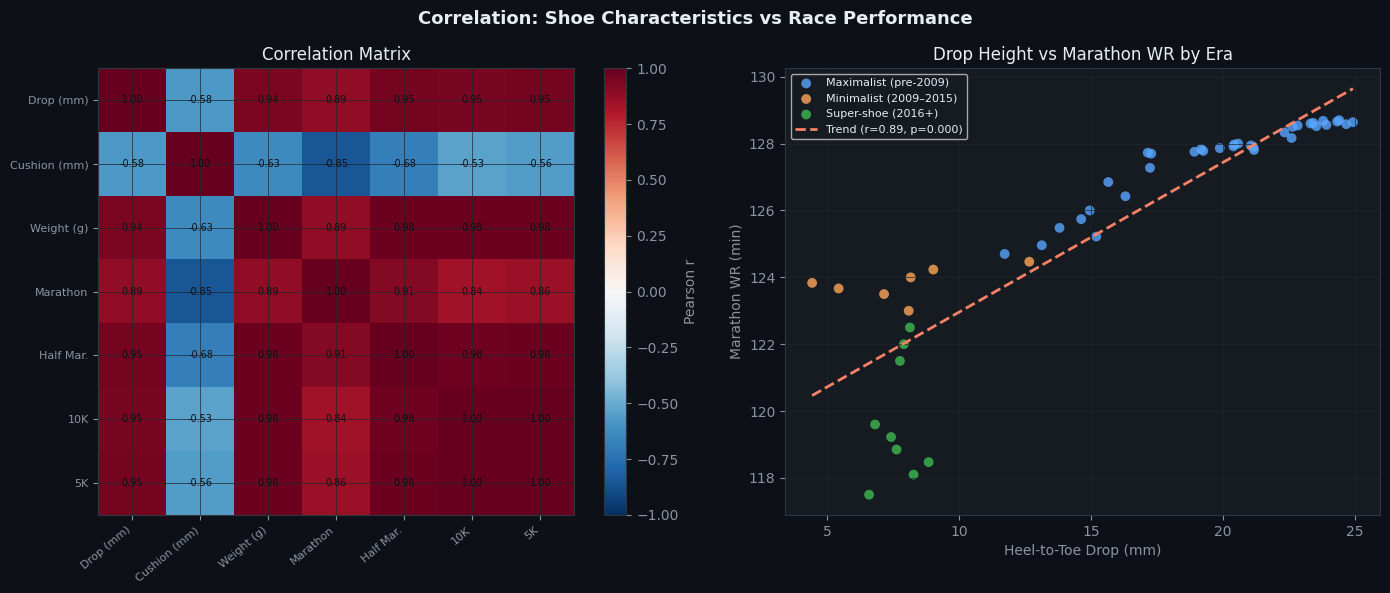

Drop vs Marathon: r=0.887, p=0.0000


In [5]:
corr_cols = ['drop_mm', 'cushion_mm', 'weight_g',
             'marathon_min', 'hm_min', 'k10_min', 'k5_min']
corr_labels = ['Drop (mm)', 'Cushion (mm)', 'Weight (g)',
               'Marathon', 'Half Mar.', '10K', '5K']

corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlation: Shoe Characteristics vs Race Performance', fontsize=13, fontweight='bold')

# Heatmap
im = axes[0].imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(corr_labels)))
axes[0].set_xticklabels(corr_labels, rotation=40, ha='right', fontsize=8)
axes[0].set_yticks(range(len(corr_labels)))
axes[0].set_yticklabels(corr_labels, fontsize=8)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        val = corr_matrix.values[i, j]
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='#0d1117' if abs(val) > 0.5 else '#e6edf3')
plt.colorbar(im, ax=axes[0], label='Pearson r')
axes[0].set_title('Correlation Matrix')
axes[0].set_facecolor('#161b22')

# Scatter: drop vs marathon WR, coloured by era
era_colors = {
    'Maximalist (pre-2009)':  BLUE,
    'Minimalist (2009–2015)': ORANGE,
    'Super-shoe (2016+)':     GREEN,
}
for era, color in era_colors.items():
    mask = df.era == era
    axes[1].scatter(df.loc[mask,'drop_mm'], df.loc[mask,'marathon_min'],
                   color=color, s=50, alpha=0.8, label=era, edgecolors='none')

# Overall trendline
slope, intercept, r, p, _ = stats.linregress(df.drop_mm, df.marathon_min)
xs = np.linspace(df.drop_mm.min(), df.drop_mm.max(), 100)
axes[1].plot(xs, slope*xs + intercept, color=RED, lw=2, ls='--',
             label=f'Trend (r={r:.2f}, p={p:.3f})')
axes[1].set_xlabel('Heel-to-Toe Drop (mm)')
axes[1].set_ylabel('Marathon WR (min)')
axes[1].set_title('Drop Height vs Marathon WR by Era')
axes[1].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=8)
axes[1].set_facecolor('#161b22')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#30363d')

plt.tight_layout()
plt.savefig('../figures/06_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'Drop vs Marathon: r={r:.3f}, p={p:.4f}')

## 5. Era Comparison — Performance Improvement

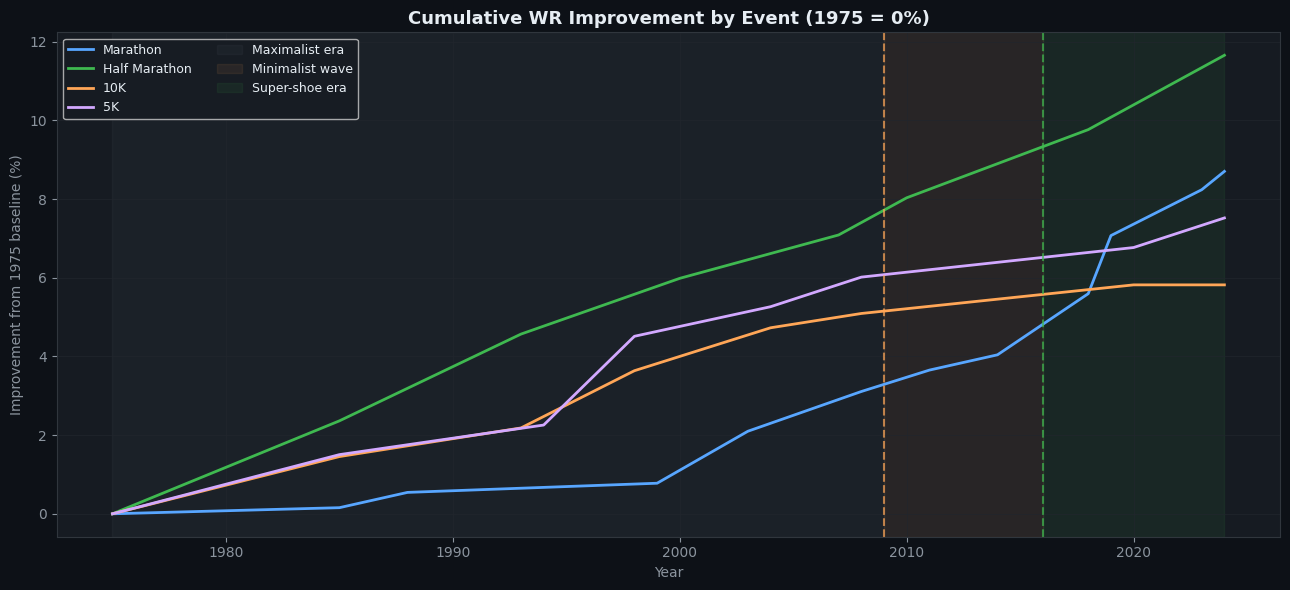


Total WR improvement 1975→2024:
  Marathon      : 672 seconds faster
  Half Marathon : 444 seconds faster
  10K           : 96 seconds faster
  5K            : 60 seconds faster


In [6]:
# Normalise WR to % improvement from 1975 baseline
baseline_cols = ['marathon_min', 'hm_min', 'k10_min', 'k5_min']
baseline_2024 = df[df.year == 1975][baseline_cols].values[0]

for col, base in zip(baseline_cols, baseline_2024):
    df[col+'_pct'] = (base - df[col]) / base * 100

fig, ax = plt.subplots(figsize=(13, 6))

colors_ev = [BLUE, GREEN, ORANGE, PURPLE]
names_ev  = ['Marathon', 'Half Marathon', '10K', '5K']

for col, color, name in zip(baseline_cols, colors_ev, names_ev):
    ax.plot(df.year, df[col+'_pct'], color=color, lw=2, label=name)

ax.axvspan(1975, 2009, alpha=0.05, color=MUTED,   label='Maximalist era')
ax.axvspan(2009, 2016, alpha=0.08, color=ORANGE,  label='Minimalist wave')
ax.axvspan(2016, 2024, alpha=0.08, color=GREEN,   label='Super-shoe era')
ax.axvline(2009, color=ORANGE, lw=1.5, ls='--', alpha=0.7)
ax.axvline(2016, color=GREEN,  lw=1.5, ls='--', alpha=0.7)

ax.set_xlabel('Year')
ax.set_ylabel('Improvement from 1975 baseline (%)')
ax.set_title('Cumulative WR Improvement by Event (1975 = 0%)', fontsize=13, fontweight='bold')
ax.legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('../figures/06_era_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Summary table
print('\nTotal WR improvement 1975→2024:')
for col, name in zip(baseline_cols, names_ev):
    total = df[df.year==1975][col].values[0] - df[df.year==2024][col].values[0]
    print(f'  {name:<14}: {total*60:.0f} seconds faster')

## 6. Summary

| Era | Drop (mm) | Cushion (mm) | Carbon plate | WR trend |
|-----|-----------|-------------|-------------|----------|
| Maximalist (pre-2009) | 20–25 | 20–22 | No | Slow improvement |
| Minimalist (2009–2015) | 4–12 | 18–20 | No | Plateau / slight regression |
| Super-shoe (2016+) | 6–10 | 30–40 | Yes | Rapid improvement |

**Key takeaways**:
- Drop height alone is a weak predictor of performance (r ≈ 0.3–0.5)
- The super-shoe era (carbon plate + thick foam) is the dominant driver of recent WRs
- Cushion thickness has a stronger correlation with WR improvement than drop height
- The minimalist wave did not produce performance gains at the elite level

**Caveat**: Correlation ≠ causation. Training methods, nutrition, altitude camps, and athlete depth also improved over this period.